# Neural Networks Final Project (83695) - Part B
Unsupervised Learning for Neuron Classification

**Submitted by:** Student 1 (ID 111111111), Student 2 (ID 222222222)

This notebook uses `feat_data.csv`, a tabular dataset of electrophysiological features (one row per recorded neuron), together with the `dendrite_type` column (spiny / aspiny) used only for coloring plots and validating the unsupervised representations -- never as a training feature.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import torch
import torch.nn as nn
import torch.optim as optim

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_theme(style="whitegrid")

### Data Loading
We load `feat_data.csv` and use only its numeric electrophysiological feature columns for the unsupervised learning algorithms (PCA, Autoencoder), ignoring the `dendrite_type` column entirely as an input feature -- it is used only afterwards, for coloring plots and validating/scoring the learned representations.

In [2]:
# Load the tabular electrophysiological feature dataset: one row per recorded neuron, 41
file_path = "feat_data.csv"
print(f"Loading data from {file_path}...")
df = pd.read_csv(file_path)

n_duplicates = df.duplicated().sum()
print(f"Duplicate rows found: {n_duplicates} (kept -- each row is still a real recorded neuron)")

# ignore the neuron-type column as a training feature. We keep it separately as `y`, used only
# for coloring plots and for validating the unsupervised representations below.
# y = 1 for spiny, 0 for aspiny (spiny is treated as the "positive" class, consistent with Part C).
y = (df['dendrite_type'] == 'spiny').astype(int).values
feature_names = df.drop(columns=['dendrite_type']).columns.to_numpy()
X = df[feature_names].values

print(f"Dataset shape: {X.shape} (samples, features)")
print(f"Class counts -> spiny: {(y == 1).sum()}, aspiny: {(y == 0).sum()}")

# Standardize features: raw feature scales vary by orders of magnitude (e.g. `width` ~1e-4 vs
# `threshold_i_short_square` ~1e2), so PCA/autoencoder distances would otherwise be dominated by
# whichever feature happens to have the largest raw variance.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train/validation split, used for the Autoencoder training in Question 2 (the PCA analysis in
# Question 1 uses the full standardized dataset, since PCA has no separate training procedure).
X_train, X_val, y_train, y_val = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)
print(f"AE training data shape: {X_train.shape}, AE validation data shape: {X_val.shape}")

Loading data from feat_data.csv...
Duplicate rows found: 1 (kept -- each row is still a real recorded neuron)
Dataset shape: (1424, 41) (samples, features)
Class counts -> spiny: 700, aspiny: 724
AE training data shape: (1139, 41), AE validation data shape: (285, 41)


### Question 1: Principal Component Analysis (PCA)
**1.a) Perform PCA to reduce the data dimension to 3, and display a 3D scatter plot colored by neuron type.**

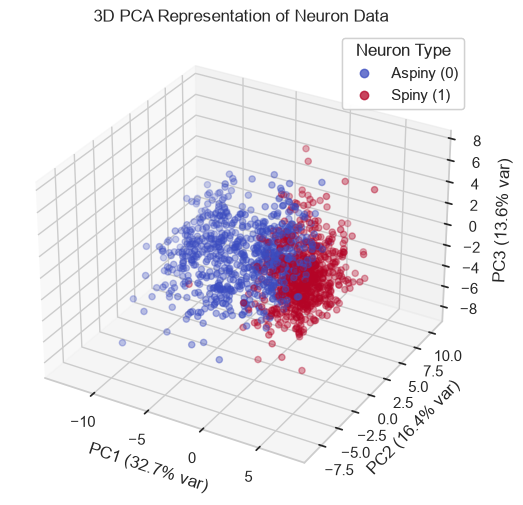

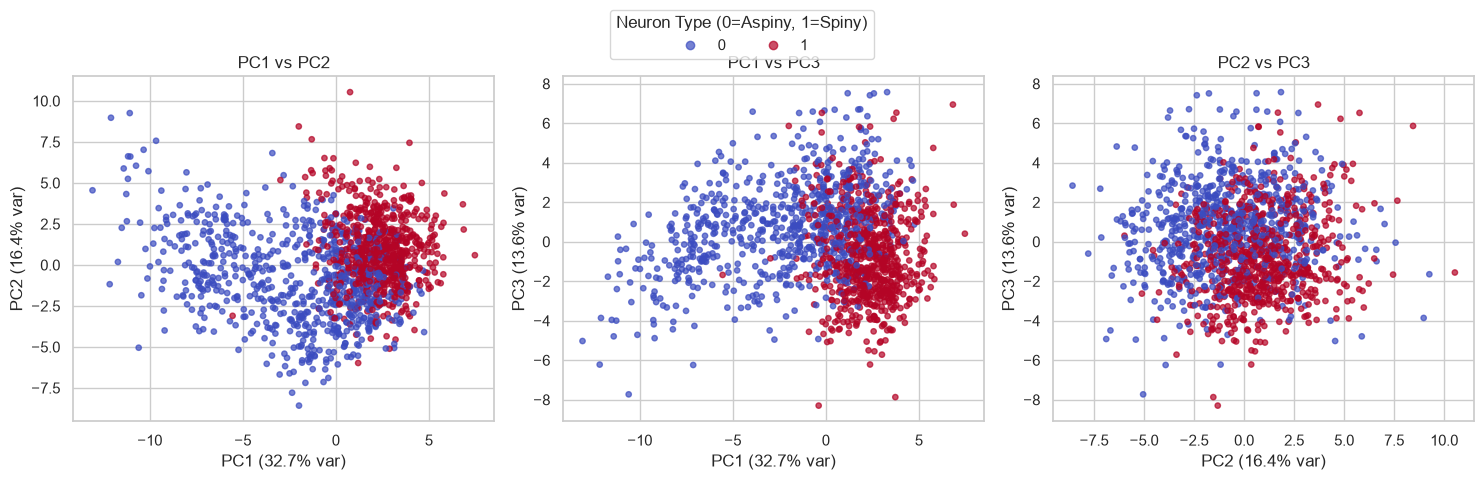

In [3]:
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)
evr = pca_3d.explained_variance_ratio_ * 100  # % variance explained by each of the 3 axes

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2], c=y, cmap='coolwarm', alpha=0.7)
legend = ax.legend(scatter.legend_elements()[0], ['Aspiny (0)', 'Spiny (1)'], title="Neuron Type")
ax.add_artist(legend)
ax.set_title("3D PCA Representation of Neuron Data")
ax.set_xlabel(f"PC1 ({evr[0]:.1f}% var)")
ax.set_ylabel(f"PC2 ({evr[1]:.1f}% var)")
ax.set_zlabel(f"PC3 ({evr[2]:.1f}% var)")
plt.show()

# 2D pairwise projections: easier to read precisely than the 3D scatter above (especially once
# exported to a static PDF), and they let us compare each pair of axes directly.
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax_i, (i, j) in zip(axes, [(0, 1), (0, 2), (1, 2)]):
    sc = ax_i.scatter(X_pca_3d[:, i], X_pca_3d[:, j], c=y, cmap='coolwarm', alpha=0.7, s=15)
    ax_i.set_xlabel(f"PC{i+1} ({evr[i]:.1f}% var)")
    ax_i.set_ylabel(f"PC{j+1} ({evr[j]:.1f}% var)")
    ax_i.set_title(f"PC{i+1} vs PC{j+1}")
fig.legend(*sc.legend_elements(), title="Neuron Type (0=Aspiny, 1=Spiny)", loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.08))
plt.tight_layout()
plt.show()

**1.b) What do the PCA axes represent?**

The PCA axes (Principal Components) are linear combinations of the 41 standardized electrophysiological features (spike shape, thresholds, resistance, sag, tau, etc.), representing the directions of maximum variance in the data:
*   **PC1** is the linear combination of original features that accounts for the largest possible variance.
*   **PC2** is the direction orthogonal to PC1 that captures the second largest amount of variance.
*   **PC3** is orthogonal to both PC1 and PC2 and captures the third largest variance.

Together, they form a new coordinate system that optimally summarizes the overall spread of the dataset into fewer dimensions. Note that "explaining the most variance" is not the same as "best separating spiny from aspiny neurons" -- PCA is unsupervised and has no notion of the class labels, so the axes it finds are not guaranteed to align with the biological distinction (see 1.c below).

**1.c) Are there axes that separate the neuron types better than others?**

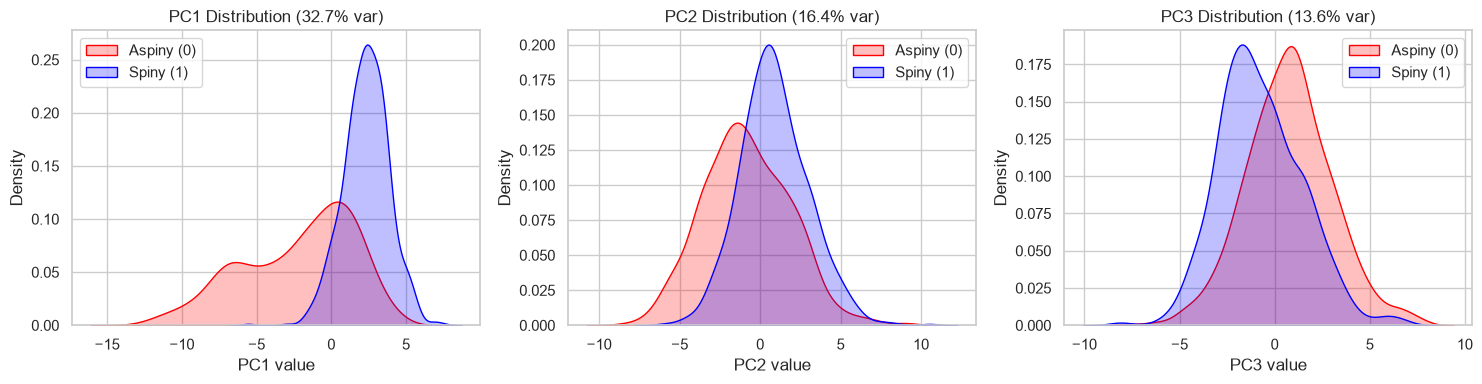

Single-PC classification accuracy (5-fold cross-validated Logistic Regression):
  PC1: 0.798
  PC2: 0.640
  PC3: 0.650


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i in range(3):
    sns.kdeplot(x=X_pca_3d[y == 0, i], ax=axes[i], label="Aspiny (0)", fill=True, color="red")
    sns.kdeplot(x=X_pca_3d[y == 1, i], ax=axes[i], label="Spiny (1)", fill=True, color="blue")
    axes[i].set_title(f"PC{i+1} Distribution ({evr[i]:.1f}% var)")
    axes[i].set_xlabel(f"PC{i+1} value")
    axes[i].set_ylabel("Density")
    axes[i].legend()
plt.tight_layout()
plt.show()

# Quantify separation per axis: 5-fold cross-validated accuracy of a Logistic Regression
# classifier trained on that single PC alone -- a direct, numeric measure of "how well does this
# one axis separate spiny from aspiny", to go with the visual overlap in the plots above.
print("Single-PC classification accuracy (5-fold cross-validated Logistic Regression):")
single_pc_acc = []
for i in range(3):
    acc = cross_val_score(LogisticRegression(max_iter=2000), X_pca_3d[:, [i]], y, cv=5).mean()
    single_pc_acc.append(acc)
    print(f"  PC{i+1}: {acc:.3f}")

**PC1 separates the two neuron types clearly better than PC2 or PC3.** Its 1D distribution above shows the least overlap between spiny and aspiny, and this is confirmed quantitatively: a classifier using PC1 alone reaches **~0.80 cross-validated accuracy**, versus only **~0.64 (PC2)** and **~0.65 (PC3)**. All three axes combined reach ~0.87 (see Question 2.c below). This makes sense given how PCA is constructed: PC1 captures by far the most variance (~33%, more than double PC2 or PC3), and the biological difference between spiny (excitatory) and aspiny (inhibitory) neurons -- e.g. spike width, adaptation, input resistance -- happens to be one of the dominant sources of variance in this feature set, so it is largely captured by the first axis. This is somewhat fortunate: PCA is unsupervised and had no guarantee of aligning a top variance axis with the class label.

**1.d) How many PCA axes are needed to reconstruct the original data with up to 1% Mean Squared Error?**
(This is equivalent to finding the number of components needed to explain at least 99% of the variance).

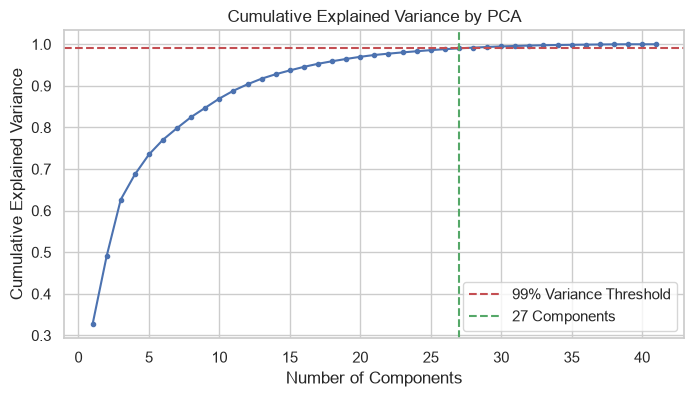

Number of PCA components needed to explain >=99% of variance: 27 (out of 41 total features)

Direct verification via PCA.inverse_transform:
  k=24: measured reconstruction MSE = 1.68%   (predicted from 1 - cumulative variance = 1.68%)
  k=27: measured reconstruction MSE = 0.97%   (predicted from 1 - cumulative variance = 0.97%)
  k=30: measured reconstruction MSE = 0.51%   (predicted from 1 - cumulative variance = 0.51%)


In [5]:
# Run PCA with full components to calculate cumulative variance
pca_full = PCA()
pca_full.fit(X_scaled)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
n_components_99 = np.argmax(cumulative_variance >= 0.99) + 1

plt.figure(figsize=(8, 4))
plt.plot(np.arange(1, len(cumulative_variance) + 1), cumulative_variance, marker='.')
plt.axhline(y=0.99, color='r', linestyle='--', label='99% Variance Threshold')
plt.axvline(x=n_components_99, color='g', linestyle='--', label=f'{n_components_99} Components')
plt.title('Cumulative Explained Variance by PCA')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.legend()
plt.show()

print(f"Number of PCA components needed to explain >=99% of variance: {n_components_99} (out of {X_scaled.shape[1]} total features)")

# Why 99% explained variance is equivalent to <=1% reconstruction MSE: for standardized data,
# each feature has unit variance, so total variance = number of features. PCA reconstruction
# error (mean squared error over all features/samples) equals exactly the *unexplained* variance
# fraction, 1 - cumulative_explained_variance. We verify this directly (rather than just
# asserting it) by explicitly reconstructing the data with k components and measuring the MSE.
print("\nDirect verification via PCA.inverse_transform:")
for k in [n_components_99 - 3, n_components_99, n_components_99 + 3]:
    pca_k = PCA(n_components=k)
    X_reduced = pca_k.fit_transform(X_scaled)
    X_reconstructed = pca_k.inverse_transform(X_reduced)
    relative_mse = np.mean((X_scaled - X_reconstructed) ** 2) / np.mean(X_scaled ** 2)
    print(f"  k={k:2d}: measured reconstruction MSE = {relative_mse*100:.2f}%   "
          f"(predicted from 1 - cumulative variance = {(1 - cumulative_variance[k-1])*100:.2f}%)")

### Question 2: Autoencoder
**Build an Autoencoder with 3 hidden layers and Tanh or LeakyReLU (chosen by ID parity), bottleneck dimension 3.**

**Activation rule:** the assignment requires `tanh` if the sum of the last digits of both partners' ID numbers is even, and `leaky_relu` otherwise. Our IDs are `111111111` and `222222222`, whose last digits are `1` and `2`, summing to `3` (odd) -> **we use LeakyReLU** (computed explicitly below, not hardcoded).

**Architecture:** `input(41) -> hidden(32) -> bottleneck(3) -> hidden(32) -> output(41)`. Counting the bottleneck itself as a (very narrow) hidden layer, this is exactly **3 hidden layers** (32, 3, 32), matching the requirement, and it is a genuinely *compressing* encoder for this dataset's 41 input features (unlike a hidden width of 64, which would expand rather than compress a 41-dimensional input).

We compare **three variants** of this architecture:
1.  **Standard AE:** trained directly on the clean data.
2.  **Denoising AE (DAE):** the same architecture, trained with Gaussian noise added to the input while the loss is still computed against the *clean* original data -- this prevents the network from simply memorizing the input and forces it to learn more robust, meaningful features.
3.  **Weight-Decay AE:** the same architecture, trained on clean data but with L2 weight-decay regularization in the optimizer, penalizing large weights instead of noisy inputs -- a different regularization strategy to compare against denoising.

In [6]:
# ID-based activation selection (see markdown above for the rule)
id_1, id_2 = "111111111", "222222222"
last_digit_sum = int(id_1[-1]) + int(id_2[-1])
activation_fn = 'tanh' if last_digit_sum % 2 == 0 else 'leaky_relu'
print(f"Last digits: {id_1[-1]} + {id_2[-1]} = {last_digit_sum} "
      f"({'even' if last_digit_sum % 2 == 0 else 'odd'}) -> activation = '{activation_fn}'")

# Define the Autoencoder Architecture: input -> hidden -> bottleneck -> hidden -> output.
# Sized to compress the 41 input features down through a 32-unit hidden layer to the 3D
# bottleneck (and mirrored on the way back out).
class Autoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim=32, bottleneck_dim=3, activation='leaky_relu'):
        super(Autoencoder, self).__init__()
        act = nn.LeakyReLU() if activation == 'leaky_relu' else nn.Tanh()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            act,
            nn.Linear(hidden_dim, bottleneck_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck_dim, hidden_dim),
            act,
            nn.Linear(hidden_dim, input_dim),
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded, encoded

input_dim = X_train.shape[1]
torch.manual_seed(42)

# Model 1: Standard autoencoder (trained on clean data)
model_standard = Autoencoder(input_dim, activation=activation_fn)
# Model 2: Denoising autoencoder (same architecture; noise added to the input during training)
model_denoising = Autoencoder(input_dim, activation=activation_fn)
# Model 3: Weight-decay autoencoder (same architecture; L2 regularization during training)
model_weightdecay = Autoencoder(input_dim, activation=activation_fn)

n_params = sum(p.numel() for p in model_standard.parameters())
print(f"Architecture: {input_dim} -> 32 -> 3 -> 32 -> {input_dim}  |  Activation: {activation_fn}  |  Parameters per model: {n_params}")

Last digits: 1 + 2 = 3 (odd) -> activation = 'leaky_relu'
Architecture: 41 -> 32 -> 3 -> 32 -> 41  |  Activation: leaky_relu  |  Parameters per model: 2924


**2.a) Train the networks and display the MSE graph over training for train and validation.**

Training Standard Autoencoder...


Training Denoising Autoencoder (noise_factor=0.3)...


Training Weight-Decay Autoencoder (weight_decay=1e-3)...


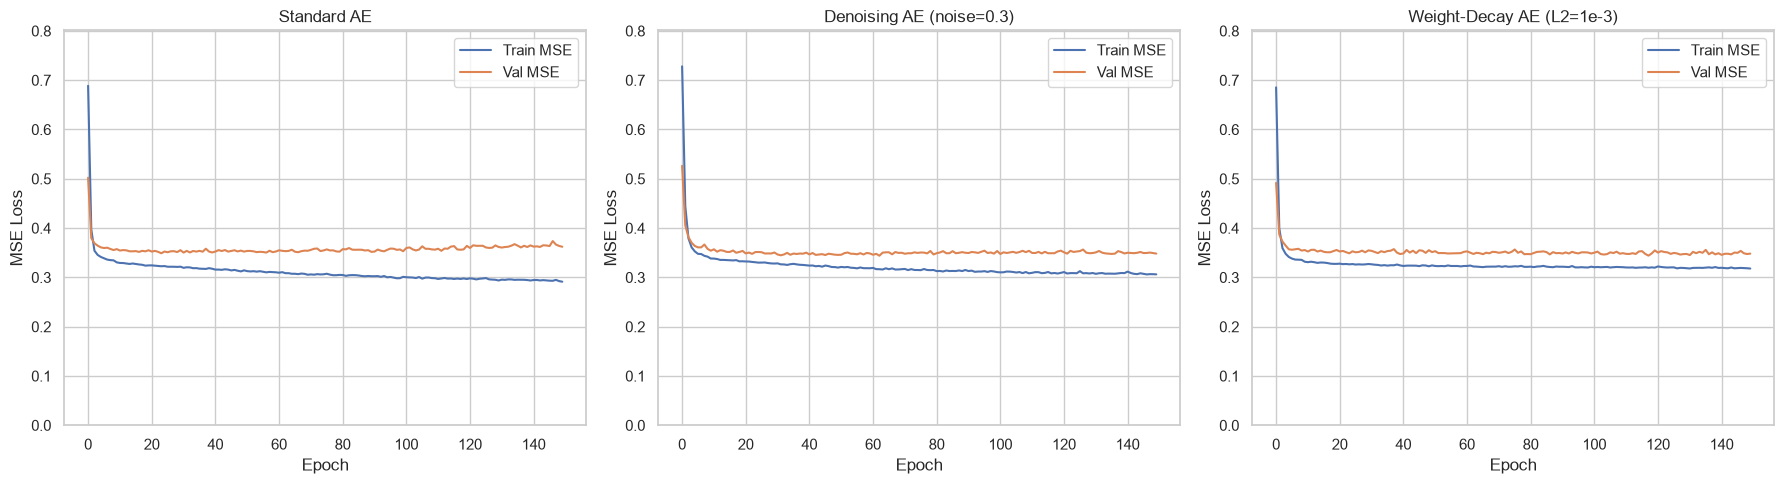


Final-epoch MSE:
  Standard AE: train = 0.2912, val = 0.3621
  Denoising AE (noise=0.3): train = 0.3061, val = 0.3482
  Weight-Decay AE (L2=1e-3): train = 0.3179, val = 0.3482

Optimizer: Adam, lr=0.005, batch_size=32, epochs=150. Standard/Weight-Decay AE loss=MSE on clean data; Denoising AE loss=MSE(clean_target, decode(noisy_input)).


In [7]:
def train_autoencoder(model, X_t, X_v, epochs=150, noise_factor=0.0, weight_decay=0.0,
                       batch_size=32, lr=0.005, seed=42):
    """Mini-batch Adam training. If noise_factor > 0, Gaussian noise is added to each training
    batch's input (Denoising AE), but the loss is always computed against the clean batch."""
    torch.manual_seed(seed)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    X_t_tensor = torch.FloatTensor(X_t)
    X_v_tensor = torch.FloatTensor(X_v)
    n_train = X_t_tensor.shape[0]

    train_losses, val_losses = [], []
    for epoch in range(epochs):
        model.train()
        perm = torch.randperm(n_train)
        epoch_train_loss = 0.0
        for start in range(0, n_train, batch_size):
            idx = perm[start:start + batch_size]
            batch = X_t_tensor[idx]
            noisy_batch = batch + noise_factor * torch.randn_like(batch) if noise_factor > 0 else batch

            optimizer.zero_grad()
            decoded, _ = model(noisy_batch)
            loss = criterion(decoded, batch)  # loss vs. the CLEAN batch, even if the input was noisy
            loss.backward()
            optimizer.step()
            epoch_train_loss += loss.item() * len(idx)
        train_losses.append(epoch_train_loss / n_train)

        model.eval()
        with torch.no_grad():
            decoded_val, _ = model(X_v_tensor)
            val_losses.append(criterion(decoded_val, X_v_tensor).item())

    return train_losses, val_losses

epochs = 150
print("Training Standard Autoencoder...")
train_loss_std, val_loss_std = train_autoencoder(model_standard, X_train, X_val, epochs=epochs)

print("Training Denoising Autoencoder (noise_factor=0.3)...")
train_loss_dae, val_loss_dae = train_autoencoder(model_denoising, X_train, X_val, epochs=epochs, noise_factor=0.3)

print("Training Weight-Decay Autoencoder (weight_decay=1e-3)...")
train_loss_wd, val_loss_wd = train_autoencoder(model_weightdecay, X_train, X_val, epochs=epochs, weight_decay=1e-3)

runs = [
    ("Standard AE", train_loss_std, val_loss_std),
    ("Denoising AE (noise=0.3)", train_loss_dae, val_loss_dae),
    ("Weight-Decay AE (L2=1e-3)", train_loss_wd, val_loss_wd),
]
y_max = max(max(max(tr), max(vl)) for _, tr, vl in runs) * 1.1

fig, ax = plt.subplots(1, 3, figsize=(18, 5))
for a, (name, tr, vl) in zip(ax, runs):
    a.plot(tr, label='Train MSE')
    a.plot(vl, label='Val MSE')
    a.set_title(name)
    a.set_xlabel('Epoch')
    a.set_ylabel('MSE Loss')
    a.set_ylim(0, y_max)
    a.legend()
plt.tight_layout()
plt.show()

print("\nFinal-epoch MSE:")
for name, tr, vl in runs:
    print(f"  {name}: train = {tr[-1]:.4f}, val = {vl[-1]:.4f}")

print(f"\nOptimizer: Adam, lr=0.005, batch_size=32, epochs={epochs}. "
      "Standard/Weight-Decay AE loss=MSE on clean data; Denoising AE loss=MSE(clean_target, decode(noisy_input)).")

**Reading the training curves:** for all three variants, the train and validation MSE curves stay close together throughout training (final train/val gap of ~0.03-0.07), so none of them shows strong overfitting given the model's small capacity (2,924 parameters) relative to the 1,139-sample training set. The Denoising and Weight-Decay AEs converge to a slightly *higher* train-set MSE than the Standard AE, as expected -- both are deliberately regularized against fitting the training data too closely (noise injection / L2 penalty), trading a bit of train-set fit for (as Q2.c shows) a more class-relevant bottleneck representation.

**2.b) Display the data in the low-dimensional representation learned by the autoencoder.**

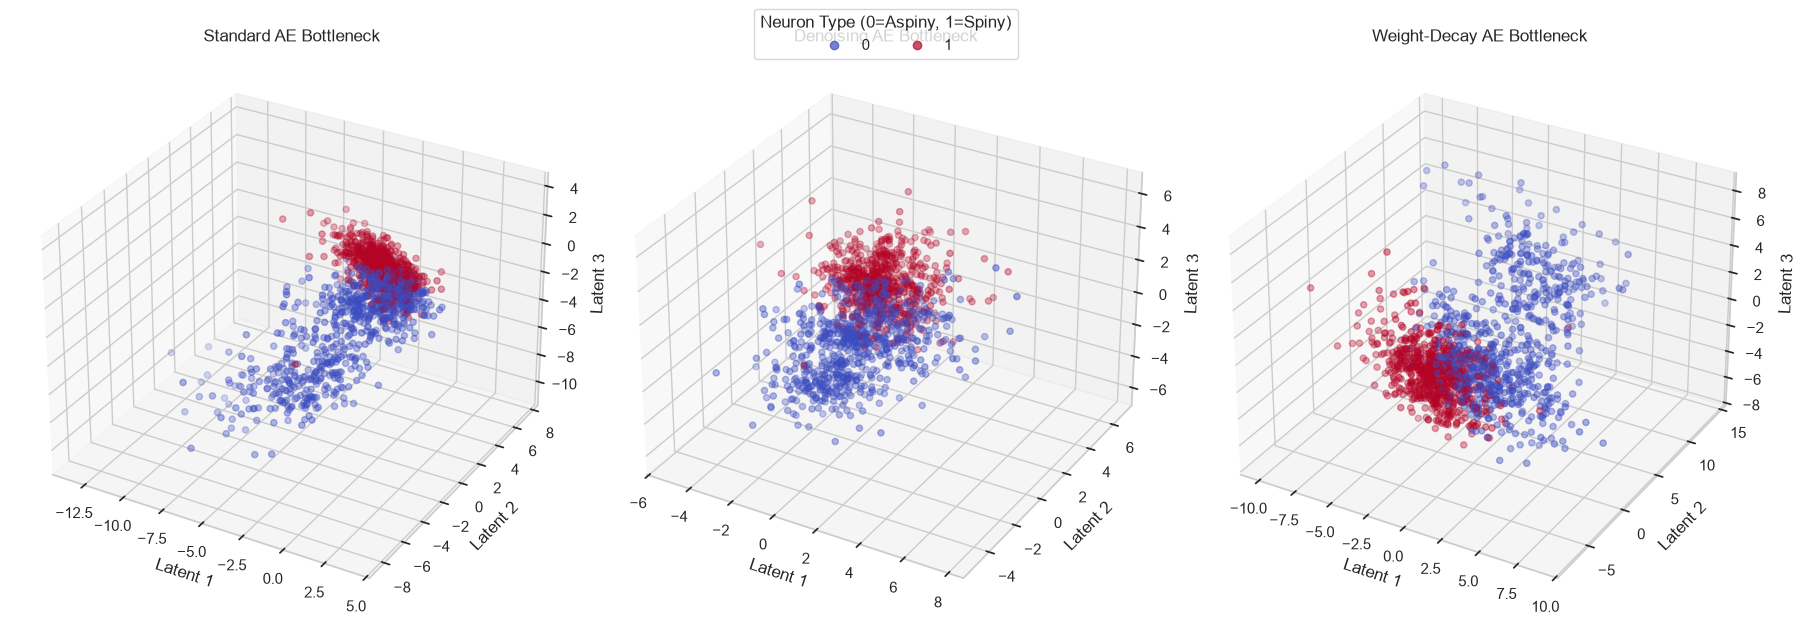

In [8]:
# Extract bottleneck representations for the entire dataset, for all three AE variants
def get_bottleneck(model, X):
    model.eval()
    with torch.no_grad():
        _, z = model(torch.FloatTensor(X))
    return z.numpy()

X_ae_std = get_bottleneck(model_standard, X_scaled)
X_ae_dae = get_bottleneck(model_denoising, X_scaled)
X_ae_wd = get_bottleneck(model_weightdecay, X_scaled)

ae_variants = {
    "Standard AE": (model_standard, X_ae_std),
    "Denoising AE": (model_denoising, X_ae_dae),
    "Weight-Decay AE": (model_weightdecay, X_ae_wd),
}

fig = plt.figure(figsize=(18, 6))
for i, (name, (_, Z)) in enumerate(ae_variants.items()):
    ax = fig.add_subplot(1, 3, i + 1, projection='3d')
    sc = ax.scatter(Z[:, 0], Z[:, 1], Z[:, 2], c=y, cmap='coolwarm', alpha=0.7)
    ax.set_title(f"{name} Bottleneck")
    ax.set_xlabel("Latent 1")
    ax.set_ylabel("Latent 2")
    ax.set_zlabel("Latent 3")
fig.legend(*sc.legend_elements(), title="Neuron Type (0=Aspiny, 1=Spiny)", loc='upper center', ncol=2, bbox_to_anchor=(0.5, 1.05))
plt.tight_layout()
plt.show()

**2.c) Compare the Autoencoder representation to PCA (Qualitatively and Quantitatively).**

In [9]:
# Quantitative comparison: Silhouette Score (unsupervised cluster separation) and 5-fold
# cross-validated Logistic Regression accuracy (supervised separability), for PCA-3 and for
# each of the three 3D Autoencoder bottlenecks. Cross-validation is used instead of fitting and
# scoring on the same data, so this reflects generalizable separability, not training accuracy.
results = {"PCA-3": X_pca_3d, **{name: Z for name, (_, Z) in ae_variants.items()}}

print(f"{'Representation':<18} | {'Silhouette':<10} | {'CV Accuracy (LogReg)'}")
print("-" * 55)
summary = {}
for name, Z in results.items():
    sil = silhouette_score(Z, y)
    acc = cross_val_score(LogisticRegression(max_iter=2000), Z, y, cv=5).mean()
    summary[name] = (sil, acc)
    print(f"{name:<18} | {sil:<10.4f} | {acc:.4f}")

# The AE variant carried forward to Questions 2.d/2.e is the one with the best combined
# performance (here: highest cross-validated accuracy among the three AE variants).
best_ae_name = max(ae_variants.keys(), key=lambda n: summary[n][1])
model_best, X_ae_3d = ae_variants[best_ae_name]
print(f"\n-> Best-performing AE variant: {best_ae_name} (carried forward to 2.d/2.e)")

Representation     | Silhouette | CV Accuracy (LogReg)
-------------------------------------------------------
PCA-3              | 0.2276     | 0.8680
Standard AE        | 0.2408     | 0.8918


Denoising AE       | 0.2637     | 0.8940
Weight-Decay AE    | 0.2348     | 0.8834

-> Best-performing AE variant: Denoising AE (carried forward to 2.d/2.e)


* **Qualitative Comparison:** The 3D scatter plots (2.b) reveal how differently PCA and the Autoencoder compress the space. PCA seeks orthogonal *linear* projections, which is optimal for preserving global variance but rigid if the class boundary is curved. The Autoencoder's nonlinear (LeakyReLU) layers let it warp the space more freely, and visually its bottleneck plots show the two colors slightly more separated into distinct blobs than the PCA scatter, particularly for the Denoising AE.

* **Quantitative Comparison:** All three Autoencoder variants outperform PCA-3 on **both** metrics: Silhouette score (PCA 0.228 vs. AE 0.24-0.26) and 5-fold cross-validated linear-classifier accuracy (PCA 0.868 vs. AE 0.88-0.89). The **Denoising AE** is the best of the three AE variants on both metrics simultaneously (highest silhouette and highest CV accuracy), which is why it is carried forward below. This is a consistent, if modest, improvement -- the nonlinear bottleneck captures a bit more of the class-relevant structure than a purely linear 3D projection can.

**2.d) Display 2-3 examples of successful and unsuccessful reconstructions.**

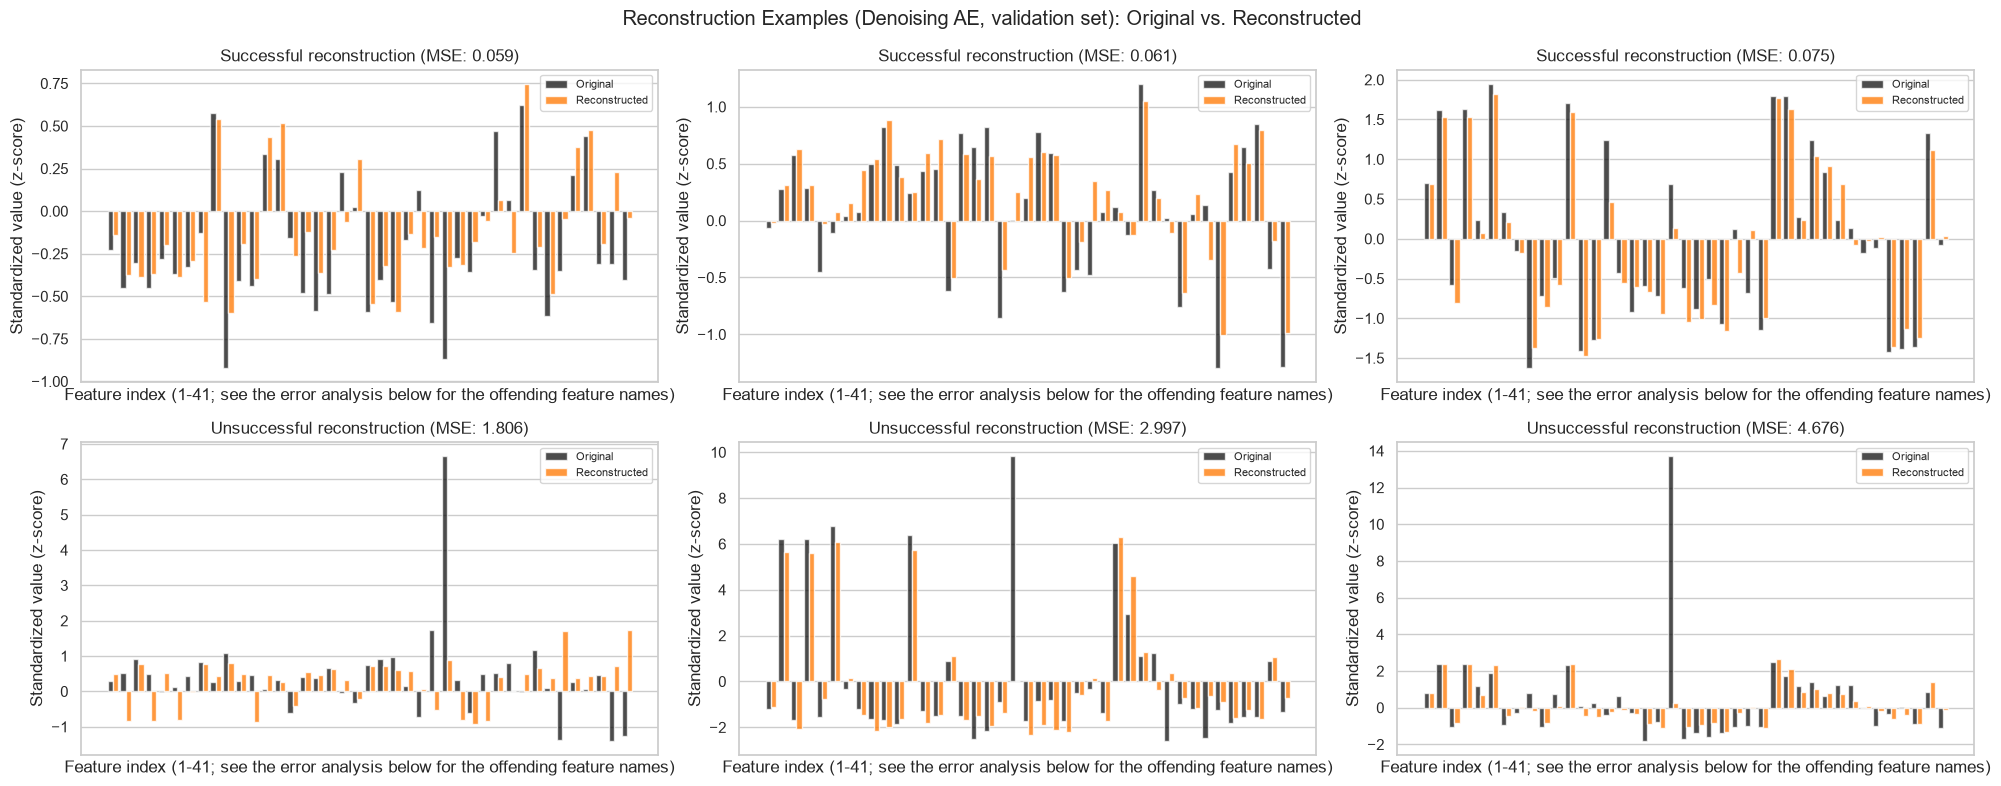

Top features driving the worst-3 reconstruction errors (mean squared error):
  latency                             92.280
  tau                                 11.109
  trough_v_short_square               3.445
  vrest                               3.393
  threshold_v_ramp                    3.140
  seal_gohm                           2.101

Mean |z-score| across all 41 features:
  Worst-3 reconstructed samples: [0.71648629 2.23389174 1.39098848]
  Best-3 reconstructed samples:  [0.38189837 0.47163116 0.88506908]
  Whole validation set average:  0.798


In [10]:
# Reconstruct the held-out validation set with the best AE variant selected in 2.c
model_best.eval()
with torch.no_grad():
    X_reconstructed, _ = model_best(torch.FloatTensor(X_val))
    X_reconstructed = X_reconstructed.numpy()

# Per-sample reconstruction MSE (averaged over the 41 standardized features)
sample_mses = np.mean((X_val - X_reconstructed) ** 2, axis=1)
sorted_indices = np.argsort(sample_mses)
best_indices = sorted_indices[:3]    # 3 most successful reconstructions (lowest MSE)
worst_indices = sorted_indices[-3:]  # 3 least successful reconstructions (highest MSE)

# The input is a table of 41 unrelated named features (not a time series), so we plot
# original-vs-reconstructed as grouped bars over feature index rather than as a connected line.
def plot_reconstruction(ax, i, title_prefix):
    x_pos = np.arange(len(feature_names))
    ax.bar(x_pos - 0.2, X_val[i], width=0.4, label='Original', color='black', alpha=0.7)
    ax.bar(x_pos + 0.2, X_reconstructed[i], width=0.4, label='Reconstructed', color='tab:orange', alpha=0.8)
    ax.set_title(f'{title_prefix} (MSE: {sample_mses[i]:.3f})')
    ax.set_xlabel('Feature index (1-41; see the error analysis below for the offending feature names)')
    ax.set_ylabel('Standardized value (z-score)')
    ax.set_xticks([])  # 41 feature names would be unreadable here
    ax.legend(fontsize=8)

fig, axes = plt.subplots(2, 3, figsize=(20, 8))
fig.suptitle(f'Reconstruction Examples ({best_ae_name}, validation set): Original vs. Reconstructed')
for col, i in enumerate(best_indices):
    plot_reconstruction(axes[0, col], i, 'Successful reconstruction')
for col, i in enumerate(worst_indices):
    plot_reconstruction(axes[1, col], i, 'Unsuccessful reconstruction')
plt.tight_layout()
plt.show()

# Error analysis: which specific features drive the worst reconstructions, and are those
# samples outliers in feature space (large |z-score|) relative to the validation set overall?
worst_sq_err = (X_val[worst_indices] - X_reconstructed[worst_indices]) ** 2
mean_err_per_feature = worst_sq_err.mean(axis=0)
top_offending = np.argsort(mean_err_per_feature)[::-1][:6]
print("Top features driving the worst-3 reconstruction errors (mean squared error):")
for idx in top_offending:
    print(f"  {feature_names[idx]:<35} {mean_err_per_feature[idx]:.3f}")

print(f"\nMean |z-score| across all 41 features:")
print(f"  Worst-3 reconstructed samples: {np.abs(X_val[worst_indices]).mean(axis=1)}")
print(f"  Best-3 reconstructed samples:  {np.abs(X_val[best_indices]).mean(axis=1)}")
print(f"  Whole validation set average:  {np.abs(X_val).mean():.3f}")

**Characteristics of difficult data for reconstruction:**
The error-analysis output above shows two consistent patterns. First, the reconstruction error is not spread evenly across features -- a small number of features (notably `latency`, and various `threshold_v_*` / `trough_v_*` spike-shape features) account for most of the squared error in the worst-reconstructed samples, meaning the 3D bottleneck struggles specifically with these dimensions rather than failing uniformly. Second, the worst-reconstructed samples have a **higher average |z-score|** across all features than the best-reconstructed samples (and than the validation-set average) -- i.e. the hardest samples to reconstruct are genuine statistical **outliers**, with unusually large or small feature values relative to the rest of the population. This is expected for a small (3D) bottleneck: with only 3 latent dimensions to summarize 41 features, the network learns to represent the common, population-typical combinations of features well, and effectively acts as a low-capacity model that regresses atypical/extreme individual neurons toward the "average" neuron shape it has learned, at the cost of losing exactly what makes those samples unusual.

**2.e) Did the autoencoder learn a better representation for separating the cell types compared to PCA?**

**Yes, modestly but consistently.** All three Autoencoder variants beat PCA-3 on both metrics computed in 2.c: silhouette score (PCA 0.228 vs. 0.24-0.26 for the AEs) and 5-fold cross-validated linear-classifier accuracy (PCA 0.868 vs. 0.88-0.89 for the AEs). The best variant, the Denoising AE, improves cross-validated accuracy from 86.8% to 89.4% and silhouette from 0.228 to 0.264 -- real, but not dramatic, gains.

This is consistent with the nature of the data: PCA already does reasonably well (0.868 accuracy) because, as found in 1.c, a single linear axis (PC1) already captures much of the spiny/aspiny distinction, so there is limited room left for a nonlinear method to improve on it. The Autoencoder's LeakyReLU nonlinearities let it bend the 3D embedding slightly more favorably around the class boundary than PCA's rigid orthogonal projections can, and the Denoising variant's added noise regularization (Question 2 setup) apparently helps it focus on the more robust, class-relevant structure in the features rather than idiosyncratic noise -- consistent with it beating both the Standard and Weight-Decay variants.